# 03 — Specificity, confound, and capability controls

All controls use the 155 frozen-clean-eligible raw $W_UJ$ cases from notebook 02. The decisive output-only control is evaluated for every concept on the same behavior metric. Additional controls are seeded matched-unit random ablations, rank-selected absent concepts with prompt/answer exclusions, off-target language/task capability, the upstream language-label narration case, and an identity-Jacobian/logit-lens baseline joined to the same measured core causal outcome. No control item is selected using its intervention effect. A pre-intervention rank-only feasibility audit found the initial never-top-1000 absence rule infeasible for 2/155 prompts (best ranks 986 and 750); before observing any absent-swap effect, the rule was frozen at never-top-500, which all 155 prompts satisfy.

In [1]:
import json
import os
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
metrics_path = ROOT / 'results/metrics.json'
metrics = json.loads(metrics_path.read_text())
core = metrics['twohop']['qwen2.5-7b-instruct']
primary_rows = [row for row in core['rows'] if row['direction_method'] == 'jlens_raw_wu_j' and row['measurement_status'] == 'OK']
print('Primary control population:', len(primary_rows))

Primary control population: 155


In [2]:
from src.jlens_iface import jlens_direction_bank, load_published_lens
from src.model_utils import load_model, release_model, set_seed

set_seed(1729)
bundle = load_model('Qwen/Qwen2.5-7B-Instruct')
lens = load_published_lens(bundle.model_id)
layers = core['metadata']['workspace_layers']
items = []
flat_core = []
for row in primary_rows:
    item = {
        'name': row['name'], 'prompt': row['prompt'], 'category': row['category'],
        'intermediate': row['intermediate'], 'swap_to': row['swap_to'],
        'concept_token_id': row['token_ids']['concept'],
        'foil_concept_token_id': row['token_ids']['foil_concept'],
        'target_token_id': row['token_ids']['target'], 'foil_token_id': row['token_ids']['foil'],
    }
    items.append(item)
    flat_core.append({
        'name': row['name'],
        'suppression_delta': row['output_suppression']['concept']['delta'],
        'actual_delta': row['ablation']['delta'],
        'predicted_delta': row['aggregate']['first_order_predicted_delta'],
        'write_strength': row['aggregate']['write_abs_mean'],
    })
token_bank = jlens_direction_bank(lens, bundle.lens_model, [item['concept_token_id'] for item in items], layers, fold_rms_gain=False)
direction_banks = {item['name']: token_bank[item['concept_token_id']] for item in items}
print('Prepared raw W_U J controls:', len(direction_banks), 'items ×', len(layers), 'layers')

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Prepared raw W_U J controls: 155 items × 15 layers


In [3]:
from src.controls_phase import run_controls_phase

controls = run_controls_phase(
    bundle, lens, items, direction_banks, flat_core, layers,
    n_random_draws=16,
    absent_min_rank=500,
    capability_tasks_per_intervention=4,
    seed=1729,
    output_path=ROOT / 'data/raw/03_controls_qwen7b.json',
    figures_dir=ROOT / 'results/figures',
)
release_model(bundle)

/opt/conda/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at ../aten/src/ATen/native/transformers/cuda/attention_backward.cu:102.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## Curated metrics versus raw audit trail

The complete seeded null draws, token ranks, per-position arrays, and cross-task records are saved under `data/raw/` for reproduction. `results/metrics.json` retains every per-concept control effect and null summary while omitting repetitive hashes and full rank matrices so the required versioned metrics file remains below the repository's 50 MB limit.

In [4]:
from src.metrics import save_json

curated = {key: controls[key] for key in ('seed', 'effect_sign', 'n_items', 'workspace_layers', 'core_output_suppression_assertion', 'causal_predictor_comparison', 'direction_convention_for_absent_and_language_labels', 'figures', 'limitations')}
curated['random_direction_null'] = {
    'seed': controls['random_direction_null']['seed'],
    'n_draws_per_item': controls['random_direction_null']['n_draws_per_item'],
    'direction_rule': controls['random_direction_null']['direction_rule'],
    'rows': [{key: row[key] for key in ('name', 'n_draws', 'observed_concept_delta', 'null_summary', 'empirical_comparison')} for row in controls['random_direction_null']['rows']],
}
curated['absent_concept_swap'] = {
    'selection_timing': controls['absent_concept_swap']['selection_timing'],
    'min_rank_threshold': controls['absent_concept_swap']['min_rank_threshold'],
    'candidate_token_order': controls['absent_concept_swap']['candidate_token_order'],
    'rows': [{key: row[key] for key in ('name', 'selected_absent_token_id', 'selected_absent_surface', 'selection', 'clean_metric', 'edited_metric', 'delta')} for row in controls['absent_concept_swap']['rows']],
}
curated['capability'] = controls['capability']
curated['known_narration'] = controls['known_narration']
curated['logit_lens_identity_jacobian'] = {
    'direction_definition': controls['logit_lens_identity_jacobian']['direction_definition'],
    'predictor': controls['logit_lens_identity_jacobian']['predictor'],
    'rows': [{key: row[key] for key in ('name', 'write_sum', 'write_strength', 'predicted_delta', 'actual_delta', 'clean_metric', 'ablated_metric')} for row in controls['logit_lens_identity_jacobian']['rows']],
}
metrics = json.loads(metrics_path.read_text())
metrics.setdefault('controls', {})['qwen2.5-7b-instruct'] = curated
save_json(metrics_path, metrics)
print('Curated controls merged; metrics size MiB:', metrics_path.stat().st_size / 2**20)

Curated controls merged; metrics size MiB: 20.4224910736084


In [5]:
import numpy as np
import pandas as pd

supp = controls['core_output_suppression_assertion']['comparison']
random_rows = controls['random_direction_null']['rows']
absent = np.asarray([row['delta'] for row in controls['absent_concept_swap']['rows']])
cap = controls['capability']
narr = controls['known_narration']
display(pd.DataFrame([
    {'control': 'internal ablation median |delta|', 'value': supp['median_abs_internal_effect']},
    {'control': 'output suppression median |delta|', 'value': supp['median_abs_output_effect']},
    {'control': 'random-null median SD across concepts', 'value': float(np.median([row['null_summary']['std'] for row in random_rows]))},
    {'control': 'absent swap median |delta|', 'value': float(np.median(np.abs(absent)))},
    {'control': 'fixed-text mean delta NLL', 'value': cap['general_language']['mean_delta_nll']},
    {'control': 'off-target clean accuracy', 'value': cap['twohop']['clean_accuracy']},
    {'control': 'off-target edited accuracy', 'value': cap['twohop']['edited_accuracy']},
]))
print('Known narration gate:', narr['reproduction_gate'])
display(pd.DataFrame(controls['causal_predictor_comparison']['shared_core_causal_target']).T)

,control,value
0,internal ablation median |delta|,3.125000
1,output suppression median |delta|,0.000000
2,random-null median SD across concepts,0.491381
3,absent swap median |delta|,12.671875
4,fixed-text mean delta NLL,0.066081
5,off-target clean accuracy,0.967742
6,off-target edited accuracy,0.951613


Known narration gate: {'status': 'FAIL', 'n_passages': 8, 'n_high_write': 8, 'n_low_causal': 1, 'n_clean_capable': 5, 'n_reproduced': 0, 'criterion': '>=6/8 passages jointly meet min J-Lens rank<=10 and |internal ablation delta - output suppression delta|<=0.5, and clean continuation margin>0.0', 'thresholds': {'high_write_max_min_jlens_rank': 10, 'low_causal_max_abs_delta_gap': 0.5, 'clean_capability_min_exclusive_margin': 0.0, 'minimum_joint_passages': 6}}


,status,n,estimate,ci_level,ci_low,ci_high,n_bootstrap,seed
outcome,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta
core_first_order_predictor,COMPUTED,155,0.608368,0.95,0.516766,0.692741,2000,1729
identity_j_first_order_association,COMPUTED,155,0.639409,0.95,0.551959,0.718859,2000,1729
core_write_association,COMPUTED,155,0.040911,0.95,-0.116188,0.194625,2000,1729
identity_j_write_association,COMPUTED,155,0.281778,0.95,0.112597,0.436834,2000,1729
n_name_aligned,155,155,155,155,155,155,155,155


f3_internal_vs_output_suppression /home/jovyan/j-space-thoughts/results/figures/f3_internal_vs_output_suppression.png


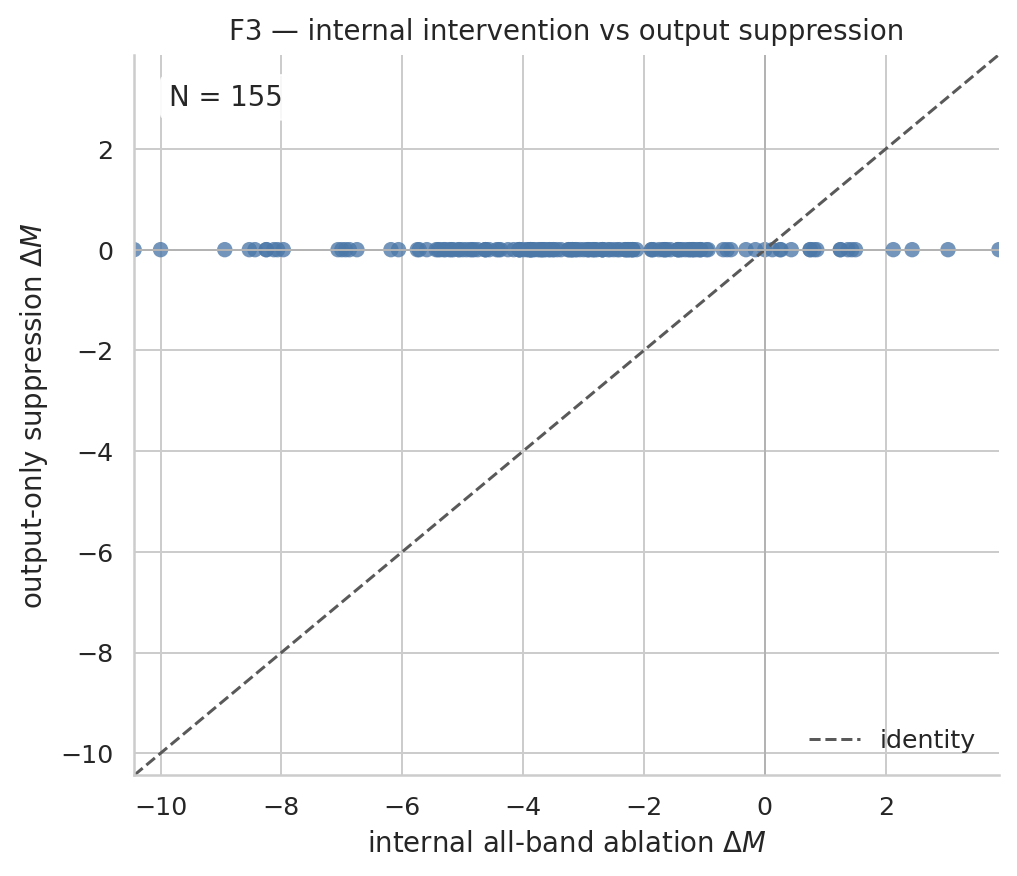

random_null /home/jovyan/j-space-thoughts/results/figures/controls_random_direction_null.png


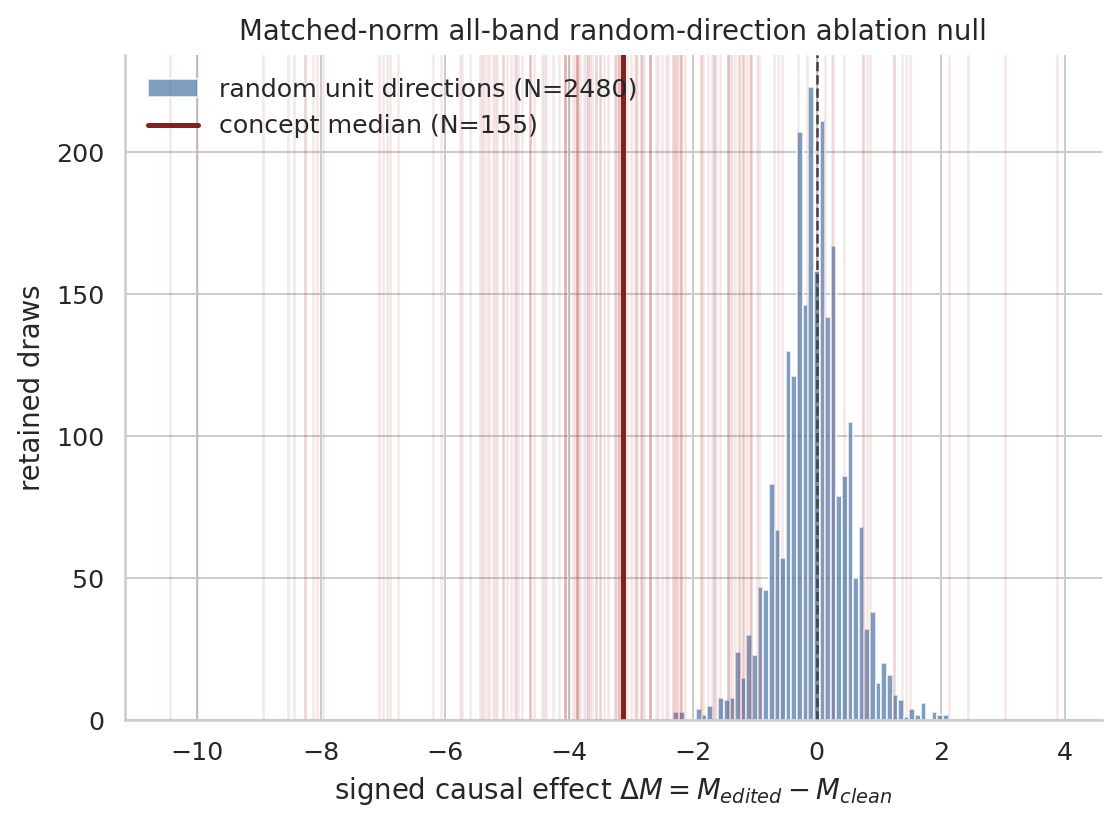

capability /home/jovyan/j-space-thoughts/results/figures/controls_capability.png


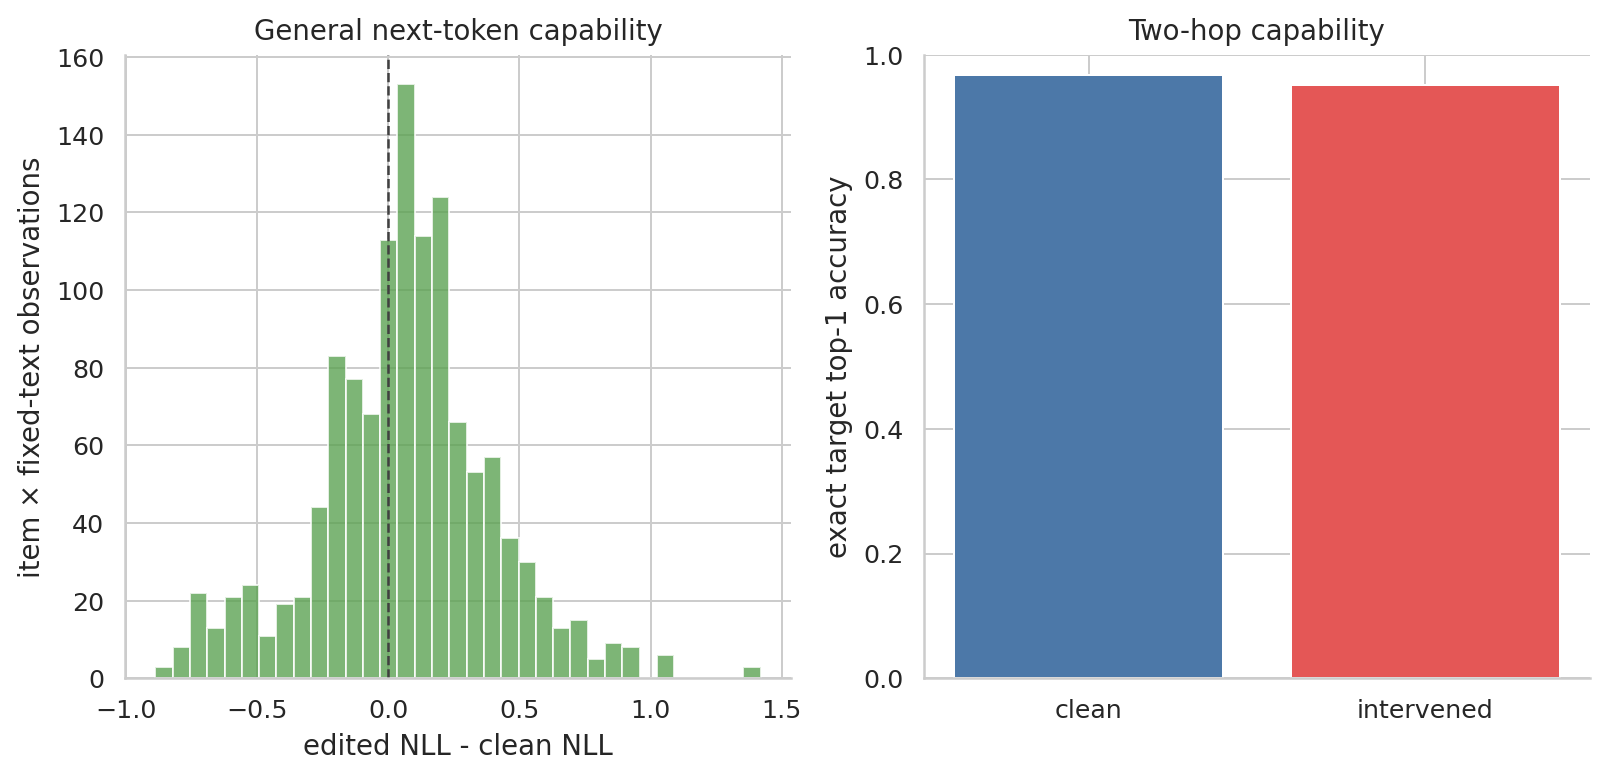

known_narration /home/jovyan/j-space-thoughts/results/figures/controls_known_narration.png


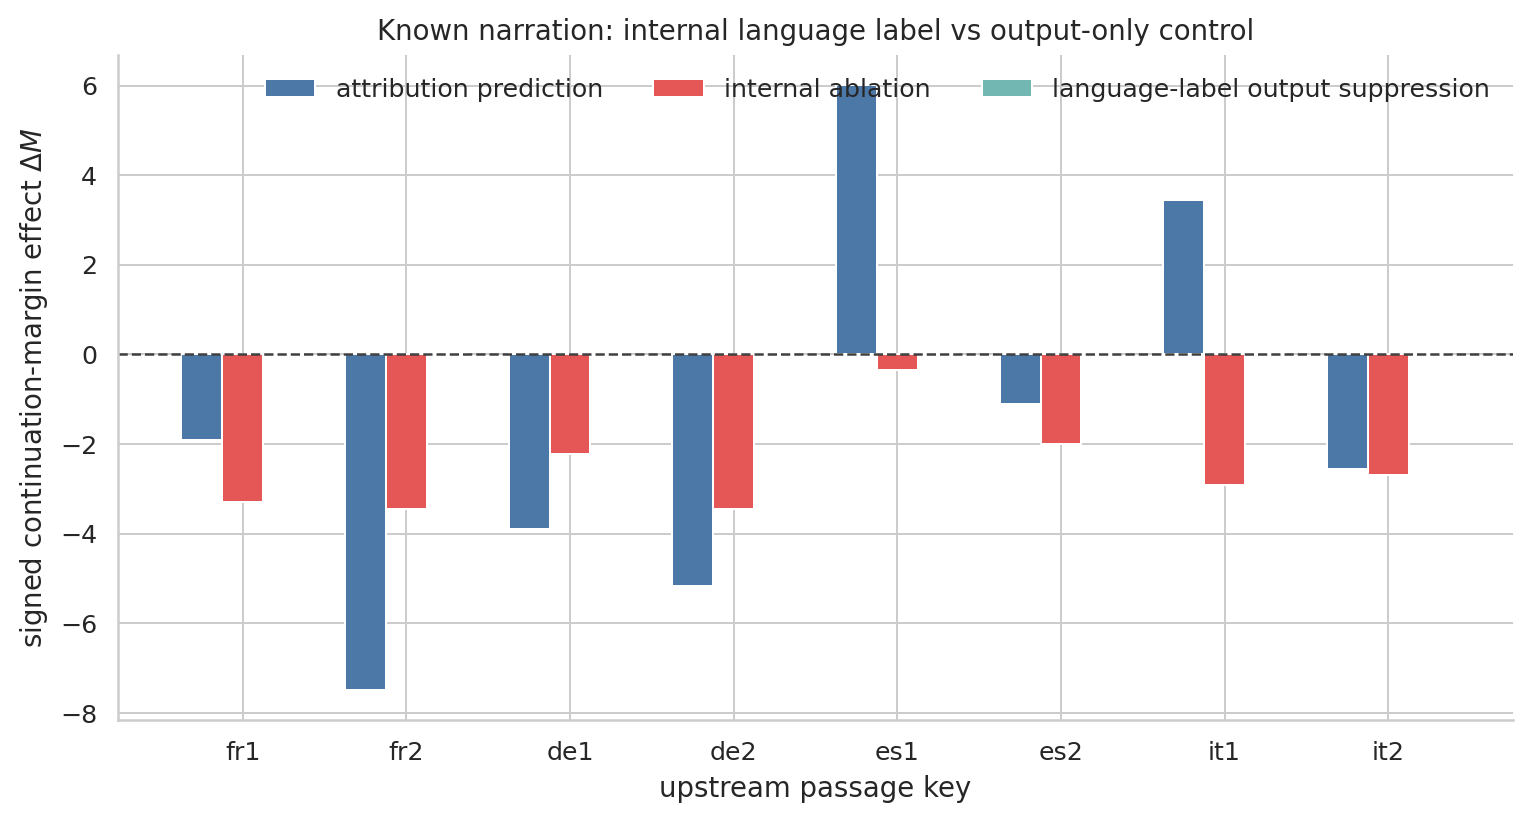

In [6]:
from IPython.display import Image, display

for name, path in controls['figures'].items():
    print(name, path)
    display(Image(filename=path))

In [7]:
print('PHASE 03 COMPUTED')
print('OUTPUT-SUPPRESSION COVERAGE', controls['core_output_suppression_assertion']['status'])
print('KNOWN-NARRATION', controls['known_narration']['status'])
if controls['known_narration']['status'] != 'PASS':
    print('The preregistered narration positive control did not reproduce; narration-class claims are not licensed at this scale.')

PHASE 03 COMPUTED
OUTPUT-SUPPRESSION COVERAGE PASS
KNOWN-NARRATION FAIL
The preregistered narration positive control did not reproduce; narration-class claims are not licensed at this scale.
